# Project Description:

The purpose of this project is to implement a neural network that performs the translation of mathematical formulae from traditional **infix notation**—where the operator appears between two operands—to **postfix** (also known as Reverse Polish Notation), where the operator follows the operands.

Infix notation is the most commonly used in human-readable mathematics (e.g., a + b), but it is inherently ambiguous without additional syntactic aids such as parentheses or operator precedence rules. This ambiguity arises because different parse trees can correspond to the same expression depending on how operations are grouped.

In contrast, postfix notation eliminates the need for parentheses entirely. The order of operations is explicitly encoded by the position of the operators relative to the operands, making it more suitable for stack-based evaluation and easier to parse programmatically.

**Example:**

Consider the ambiguous infix expression:
a + b * c

This expression can be parsed in at least two different ways:

Interpretation (Infix):	(a + b) * c	   
Equivalent Postfix: ab+c*

Interpretation (Infix):	a + (b * c)	          
Equivalent Postfix: abc*+


This project aims to learn such disambiguations and generate the correct postfix form from a given infix expression using a data-driven approach based on neural networks.

To simplify the task and control the complexity of expressions, we restrict our dataset to formulae with a maximum syntactic depth of 4. This means that the abstract syntax trees representing these expressions will have at most three levels, ensuring that the neural network operates on a bounded and manageable set of possible structures.

In [16]:
import os

# 1. Force Colab to use the Legacy Keras (Keras 2 behavior)
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 2. Verify it worked
print("TensorFlow Version:", tf.__version__)
# If successful, this should NOT say "Keras 3" in the imports

TensorFlow Version: 2.19.0


In [17]:
import numpy as np
import random
import string
import tensorflow as tf
from tensorflow.keras import layers, models

We build formulae using 6 identifiers a,b,c,d,e,f and 4 binary operators +,-,*,/.
For simplicity we do not take advantage of precedence or associativity rules for infix notation, and suppose that all binary operations as always fully parenthesizes: (e1 op e2).

In [18]:
# -------------------- Constants --------------------
OPERATORS = ['+', '-', '*', '/']
IDENTIFIERS = list('abcdef')
SPECIAL_TOKENS = ['PAD', 'SOS', 'EOS']
SYMBOLS = ['(', ')', '+', '-', '*', '/']
VOCAB = SPECIAL_TOKENS + SYMBOLS + IDENTIFIERS + ['JUNK'] #may use junk in autoregressive generation

token_to_id = {tok: i for i, tok in enumerate(VOCAB)}
id_to_token = {i: tok for tok, i in token_to_id.items()}
VOCAB_SIZE = len(VOCAB)
PAD_ID = token_to_id['PAD']
EOS_ID = token_to_id['EOS']
SOS_ID = token_to_id['SOS']

MAX_DEPTH = 4
MAX_LEN = 4*2**MAX_DEPTH -2 #enough to fit expressions at given depth (+ EOS)

In [19]:
# -------------------- Expression Generation --------------------
def generate_infix_expression(max_depth):
    if max_depth == 0:
        return random.choice(IDENTIFIERS)
    elif random.random() < 0.25:
        return generate_infix_expression(max_depth - 1)
    else:
        left = generate_infix_expression(max_depth - 1)
        right = generate_infix_expression(max_depth - 1)
        op = random.choice(OPERATORS)
        return f'({left} {op} {right})'

def tokenize(expr):
    return [c for c in expr if c in token_to_id]

def infix_to_postfix(tokens):
    precedence = {'+': 1, '-': 1, '*': 2, '/': 2}
    output, stack = [], []
    for token in tokens:
        if token in IDENTIFIERS:
            output.append(token)
        elif token in OPERATORS:
            while stack and stack[-1] in OPERATORS and precedence[stack[-1]] >= precedence[token]:
                output.append(stack.pop())
            stack.append(token)
        elif token == '(':
            stack.append(token)
        elif token == ')':
            while stack and stack[-1] != '(':
                output.append(stack.pop())
            stack.pop()
    while stack:
        output.append(stack.pop())
    return output

def encode(tokens, max_len=MAX_LEN):
    ids = [token_to_id[t] for t in tokens] + [EOS_ID]
    return ids + [PAD_ID] * (max_len - len(ids))

def decode_sequence(token_ids, id_to_token, pad_token='PAD', eos_token='EOS'):
    """
    Converts a list of token IDs into a readable string by decoding tokens.
    Stops at the first EOS token if present, and ignores PAD tokens.
    """
    tokens = []
    for token_id in token_ids:
        token = id_to_token.get(token_id, '?')
        if token == eos_token:
            break
        if token != pad_token:
            tokens.append(token)
    return ' '.join(tokens)

def generate_dataset(n,max_depth=MAX_DEPTH):
    X, Y = [], []
    for _ in range(n):
        expr = generate_infix_expression(MAX_DEPTH)
        #expr = expr_gen.generate(max_depth=max_dthep)
        infix = tokenize(expr)
        postfix = infix_to_postfix(infix)
        X.append(encode(infix))
        Y.append(encode(postfix))
    return np.array(X), np.array(Y)

#you might use the shift function for teacher-forcing
def shift_right(seqs):
    shifted = np.zeros_like(seqs)
    shifted[:, 1:] = seqs[:, :-1]
    shifted[:, 0] = SOS_ID
    return shifted

Let us define a simple dataset, and inspect a few samples. You can use a larger dataset, if you want, or directly use the generator.

In [20]:
X_train, Y_train = generate_dataset(10000)
decoder_input_train = shift_right(Y_train)

# Dataset
X_val, Y_val = generate_dataset(1000)
decoder_input_val = shift_right(Y_val)

In [21]:
i =  np.random.randint(10000)
print(i)
print("infix : ",decode_sequence(X_train[i],id_to_token))
print("posfix notation: ",decode_sequence(Y_train[i],id_to_token))
print("teacher forcing : ", decode_sequence(decoder_input_train[i],id_to_token))

7003
infix :  ( ( ( f - a ) / ( ( a / e ) / ( e / b ) ) ) * ( ( c * d ) - b ) )
posfix notation:  f a - a e / e b / / / c d * b - *
teacher forcing :  SOS f a - a e / e b / / / c d * b - *


# Constraints
* You may use any architecture (decoder-only, encoder-decoder, or other).

* The maximum number of parameters is 2 million.

* Beam search is not allowed.

* You may adapt the formula generator to your needs, but preserve its core logic—especially the frequency distribution of formulas by depth, as it may significantly influence model performance.

* You may train your model using a pre-generated fixed dataset (e.g., an array) or directly use an on-the-fly generator.




# Evaluation

We shall evaluate a generated item y_pred using "prefix accuracy", the lenght of
the initial prefix of y_pred matching the ground true y_true. This will be divided by the maximum length of y_true and y_pred (up to EOS), so that a perfect match has score 1.

* It's more informative than exact match (which is often 0)

* It’s tighter than edit distance: focuses on generation flow

* Captures where the model starts to make errors



In [22]:
def prefix_accuracy_single(y_true, y_pred, id_to_token, eos_id=EOS_ID, verbose=False):
    t_str = decode_sequence(y_true, id_to_token).split(' EOS')[0]
    p_str = decode_sequence(y_pred, id_to_token).split(' EOS')[0]
    t_tokens = t_str.strip().split()
    p_tokens = p_str.strip().split()
    # print(len(p_tokens))
    max_len = max(len(t_tokens), len(p_tokens))
    n = min(len(t_tokens), len(p_tokens))
    match_len = 0
    while match_len < n and t_tokens[match_len] == p_tokens[match_len]:
        match_len += 1
    score = match_len / max_len if max_len>0 else 0
    if score != 1:
        print(f"Predicted: {p_tokens} instead of {t_tokens}")
    if verbose:
        print("TARGET :", ' '.join(t_tokens))
        print("PREDICT:", ' '.join(p_tokens))
        print(f"PREFIX MATCH: {match_len}/{len(t_tokens)} → {score:.2f}")

    return score

In [23]:
#example
i = np.random.randint(10000)
expected = np.copy(Y_train[i])
generated = np.copy(Y_train[i])
expr_len = np.where(generated==EOS_ID)[0][0]
j = np.random.randint(expr_len)
generated[j] = EOS_ID #making shorter
prefix_accuracy_single(expected,generated,id_to_token,verbose=True)

Predicted: ['f'] instead of ['f', 'c', '/', 'b', 'c', '/', '*', 'e', '/']
TARGET : f c / b c / * e /
PREDICT: f
PREFIX MATCH: 1/9 → 0.11


0.1111111111111111

In [24]:
# --- Hyperparameters ---
EMBEDDING_DIM = 64
LSTM_UNITS = 256
DROPOUT_RATE = 0.2

# --- 1. Encoder ---
encoder_inputs = layers.Input(shape=(None,), name='encoder_inputs')
enc_emb = layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(encoder_inputs)

# KEY CHANGE: return_sequences=True
# We need the full history of the input to "attend" to it later
encoder_lstm = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, dropout=DROPOUT_RATE, name='encoder_lstm')
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# --- 2. Decoder ---
decoder_inputs = layers.Input(shape=(None,), name='decoder_inputs')
dec_emb = layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)(decoder_inputs)

# We still initialize with encoder states
decoder_lstm = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, dropout=DROPOUT_RATE, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

# --- 3. Attention Layer (The New Part) ---
# Query: What the decoder is looking for (decoder_outputs)
# Value: What the encoder knows (encoder_outputs)
attention_layer = layers.Attention(name='attention_layer')
context_vector = attention_layer([decoder_outputs, encoder_outputs])

# Combine the Context Vector (from Attention) with the Decoder Output
decoder_combined = layers.Concatenate(axis=-1, name='concat_layer')([decoder_outputs, context_vector])

# --- 4. Output ---
# We often add a dense layer to process the combined info before the softmax
decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name='output_layer')
outputs = decoder_dense(decoder_combined)

# --- Compile ---
attention_model = models.Model([encoder_inputs, decoder_inputs], outputs)
attention_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

attention_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_inputs (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 decoder_inputs (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 embedding_2 (Embedding)     (None, None, 64)             1024      ['encoder_inputs[0][0]']      
                                                                                            

In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Save the model only when 'val_accuracy' improves
checkpoint = ModelCheckpoint(
    filepath='best_model.weights.h5', # Where to save the file
    monitor='val_accuracy',           # The metric to watch
    mode='max',                       # 'max' because we want highest accuracy
    save_best_only=True,              # CRITICAL: Only save if it's better than previous best
    save_weights_only=True,           # We typically save just weights to stay under size limits
    verbose=1                         # It will print "Epoch X: val_accuracy improved..."
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Callbacks Configuration ---

# 1. Early Stopping: Stop if val_loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,                 # Stop after 3 epochs of no improvement
    restore_best_weights=True,  # Go back to the best weights automatically
    verbose=1
)

In [26]:
# --- Training ---
BATCH_SIZE = 64
EPOCHS = 30

# Note: We pass TWO inputs [X_train, decoder_input_train]
# and ONE target [Y_train]
history = attention_model.fit(
    x=[X_train, decoder_input_train],
    y=Y_train,
    validation_data=([X_val, decoder_input_val], Y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    # callbacks=[checkpoint, early_stopping]
)

Epoch 1/30
157/157 [==============================] - 15s 33ms/step - loss: 2.0847 - accuracy: 0.1995 - val_loss: 1.8904 - val_accuracy: 0.2398
Epoch 2/30
157/157 [==============================] - 2s 15ms/step - loss: 1.7192 - accuracy: 0.2681 - val_loss: 1.8313 - val_accuracy: 0.2544
Epoch 3/30
157/157 [==============================] - 3s 20ms/step - loss: 1.6682 - accuracy: 0.2907 - val_loss: 1.6081 - val_accuracy: 0.3269
Epoch 4/30
157/157 [==============================] - 2s 15ms/step - loss: 1.5121 - accuracy: 0.3966 - val_loss: 1.2742 - val_accuracy: 0.5453
Epoch 5/30
157/157 [==============================] - 2s 15ms/step - loss: 0.7785 - accuracy: 0.7544 - val_loss: 0.3099 - val_accuracy: 0.9100
Epoch 6/30
157/157 [==============================] - 2s 15ms/step - loss: 0.1769 - accuracy: 0.9563 - val_loss: 0.0541 - val_accuracy: 0.9922
Epoch 7/30
157/157 [==============================] - 2s 15ms/step - loss: 0.0626 - accuracy: 0.9889 - val_loss: 0.0448 - val_accuracy: 0.991

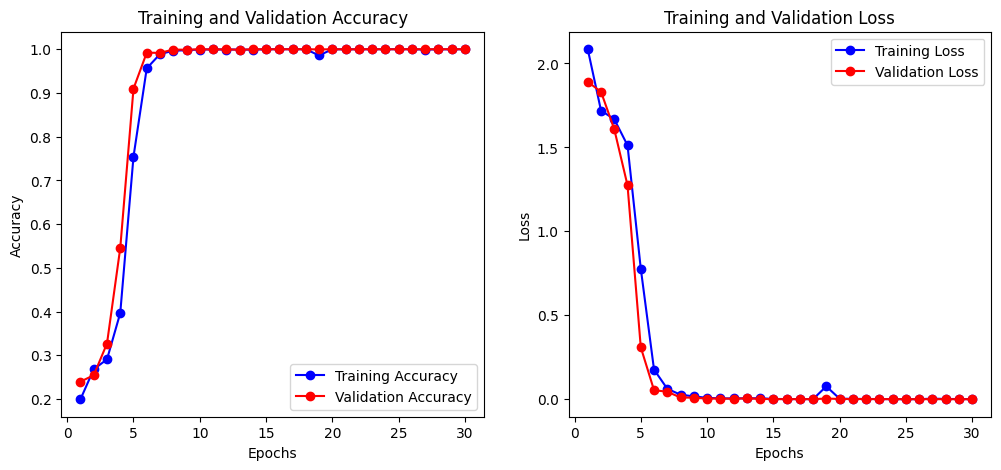

In [29]:
import matplotlib.pyplot as plt

# 1. Capture the history (you likely already have this line)
# history = model.fit(...)

# 2. Extract the data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# 3. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 4. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

For the exam, evaluate you model on a test set of 30 expressions. Repeat this evaluation 10 times, and return the mean and std for this rounds.

In [27]:
def autoregressive_decode(model, encoder_input, max_len=MAX_LEN):

    # Ensure batch dimension
    encoder_input = np.array(encoder_input)[None, :]

    # Initialize decoder input with SOS
    decoded_sequence = [SOS_ID]

    for _ in range(max_len):
        decoder_input = np.array(decoded_sequence)[None, :]

        # Forward pass
        preds = model.predict(
            [encoder_input, decoder_input],
            verbose=0
        )

        # Take the last timestep prediction
        next_token = np.argmax(preds[0, -1])

        decoded_sequence.append(next_token)

        # Stop if EOS is generated
        if next_token == EOS_ID:
            break

    return decoded_sequence


In [28]:
from tqdm.auto import tqdm # Automatically chooses the best progress bar style (Jupyter vs Terminal)

def test(no=30,rounds=10):
  rscores =[]
  for i in range(rounds):
    print("round=",i)
    X_test, Y_test = generate_dataset(no)
    scores = []
    progress_bar = tqdm(range(no), desc="Evaluation Progress")
    for j in progress_bar:

      encoder_input=X_test[j]
      generated = autoregressive_decode(attention_model, encoder_input)[1:] #remove SOS
      scores.append(prefix_accuracy_single(Y_test[j], generated, id_to_token))
    rscores.append(np.mean(scores))
  return np.mean(rscores),np.std(rscores)

res, std = test(30,10)
print("score=",res,"std=",std)

round= 0


Evaluation Progress:   0%|          | 0/30 [00:00<?, ?it/s]

round= 1


Evaluation Progress:   0%|          | 0/30 [00:00<?, ?it/s]

round= 2


...

round= 8


Evaluation Progress:   0%|          | 0/30 [00:00<?, ?it/s]

round= 9


Evaluation Progress:   0%|          | 0/30 [00:00<?, ?it/s]

score= 1.0 std= 0.0


Be sure to evalutate the generator: your model may only take as input the expression in infix format and return its translation to postifix.

If you are usuing an encoder-decoder model, generation must be done autoregressively.

# What to deliver

As usual you are supposed to deliver a single notebook witten in Keras. You are auhtorized to use Keras3 with pytorch as backend if you prefer.

Do no upload a zip file: the submission will be rejected.

The python notebook should have a clear documentation of the training phase, possibly with its history.

Please provide the network parameters by means of gdown.

@article{DBLP:journals/corr/SutskeverVL14,
  author       = {Ilya Sutskever and
                  Oriol Vinyals and
                  Quoc V. Le},
  title        = {Sequence to Sequence Learning with Neural Networks},
  journal      = {CoRR},
  volume       = {abs/1409.3215},
  year         = {2014},
  url          = {http://arxiv.org/abs/1409.3215},
  eprinttype    = {arXiv},
  eprint       = {1409.3215},
  timestamp    = {Mon, 13 Aug 2018 16:48:06 +0200},
  biburl       = {https://dblp.org/rec/journals/corr/SutskeverVL14.bib},
  bibsource    = {dblp computer science bibliography, https://dblp.org}
}